In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle
import kagglehub

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [2]:
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Dataset downloaded successfully!")
print(path)

# Set correct dataset path
dataset_path = os.path.join(path, "plantvillage dataset")

print("Dataset Path:", dataset_path)
print(os.listdir(dataset_path)[:10])

Dataset downloaded successfully!
C:\Users\HP\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3
Dataset Path: C:\Users\HP\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset
['color', 'grayscale', 'segmented']


In [3]:
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Dataset downloaded successfully!")
print(path)

dataset_path = path

Dataset downloaded successfully!
C:\Users\HP\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3


In [5]:
import os

print(os.listdir(path))

['plantvillage dataset']


In [6]:
import os

dataset_path = os.path.join(path, "plantvillage dataset", "color")

print(dataset_path)
print(os.listdir(dataset_path)[:10])

C:\Users\HP\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3\plantvillage dataset\color
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [7]:
import os

print(path)
print(os.listdir(path))

C:\Users\HP\.cache\kagglehub\datasets\abdallahalidev\plantvillage-dataset\versions\3
['plantvillage dataset']


In [9]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)


validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [10]:
classes = list(train_generator.class_indices.keys())

print(classes)
print("Number of Classes:",len(classes))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

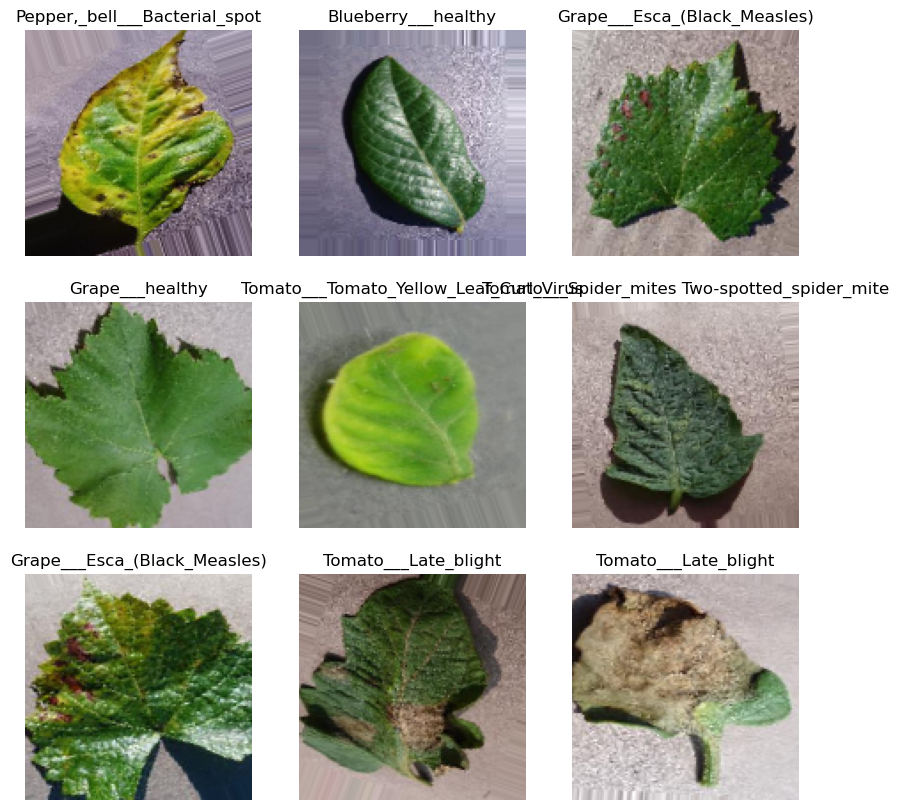

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis("off")

plt.show()

In [12]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Convolution Layer 2
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(len(classes), activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 28800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,843,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           2,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,850,822 (7.06 MB)

 Trainable params: 1,850,822 (7.06 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3,
    verbose=1
)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 466s 342ms/step - accuracy: 0.4666 - loss: 1.9157 - val_accuracy: 0.6760 - val_loss: 1.0850
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 426s 313ms/step - accuracy: 0.6030 - loss: 1.3109 - val_accuracy: 0.7488 - val_loss: 0.8335
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 3368s 2s/step - accuracy: 0.6413 - loss: 1.1706 - val_accuracy: 0.7782 - val_loss: 0.7197


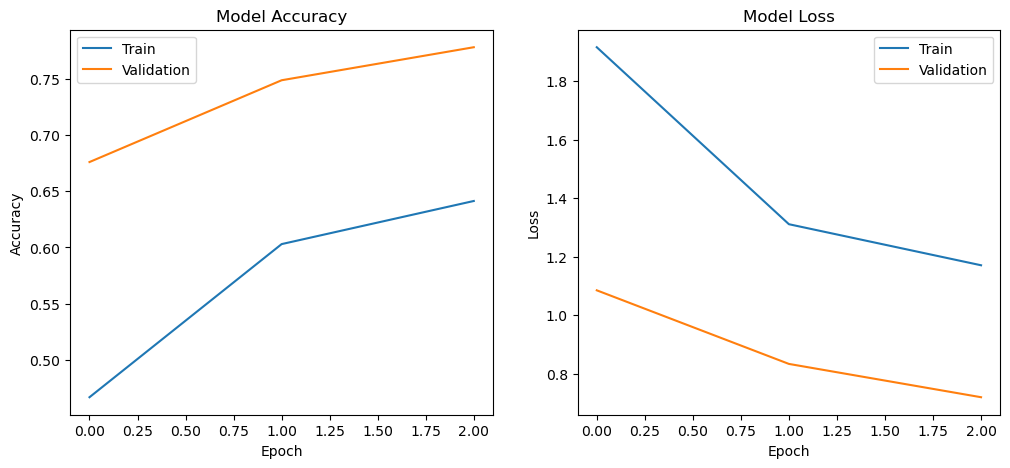

In [14]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])


# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [15]:
model.save("plant_disease_model.h5")

import pickle
with open("class_names.pkl", "wb") as f:
    pickle.dump(classes, f)

print("Model and class names saved successfully!")

Model and class names saved successfully!


In [1]:
import tensorflow as tf

model = tf.keras.models.load_model("plant_disease_model.h5")
print("Loaded Successfully")

Loaded Successfully


In [2]:
model.save("plant_disease_model_new.h5")

In [3]:
import pickle

with open("class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

print("Number of Classes:", len(class_names))
print(class_names)

Number of Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [4]:
print("Model Output Shape:", model.output_shape)

Model Output Shape: (None, 38)


In [6]:
import pickle

with open("class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

print(type(class_names))
print(len(class_names))
print(class_names)

<class 'list'>
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

In [7]:
model.input_shape

(None, 128, 128, 3)